The Lognormal Distribution

In [5]:
# Cell 2: Imports, plotting style, and helper functions
from pathlib import Path
from math import exp, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8')
rng = np.random.default_rng(42)

def lognormal_mean(mu, sigma):
    return np.exp(mu + 0.5 * sigma**2)

def lognormal_variance(mu, sigma):
    return (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)

def annualize_volatility(log_returns, periods_per_year=252):
    return log_returns.std(ddof=1) * np.sqrt(periods_per_year)


##  The Normal Distribution Basics

A random variable $X$ is **normally distributed** with mean $\mu$ and variance $\sigma^2$ if its probability density function is

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}.$$

Denoted as $X \sim N(\mu, \sigma^2)$.

The **cumulative normal distribution function** $N(a)$ gives the probability $\mathbb{P}(Z \le a)$, where $Z$ is a standard normal random variable (mean 0, variance 1).

Key probability property:
$$\mathbb{P}(-a < Z < a) = N(a) - N(-a) = N(a) - [1 - N(a)] = 2N(a) - 1.$$

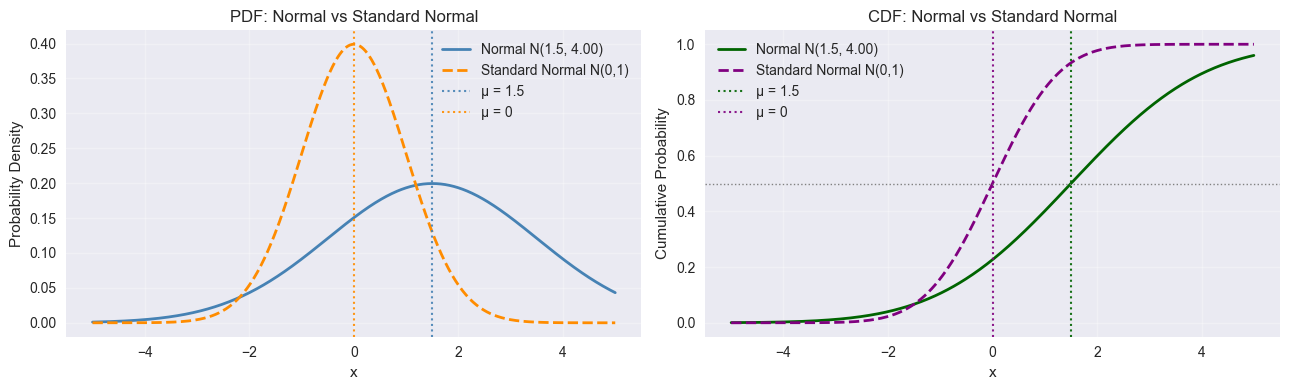

Selected checkpoints:
  General normal:  F(0) = 0.2266, F(1) = 0.4013
  Standard normal: N(0) = 0.5000, N(1) = 0.8413, N(-1) = 0.1587


In [6]:
# Cell 3: Compare normal and standard normal distributions (PDF and CDF)
mu_norm = 1.5
sigma_norm = 2.00

x_range = np.linspace(-5, 5, 600)

# General normal N(mu, sigma^2)
pdf_normal = norm.pdf(x_range, loc=mu_norm, scale=sigma_norm)
cdf_normal = norm.cdf(x_range, loc=mu_norm, scale=sigma_norm)

# Standard normal N(0, 1)
pdf_standard = norm.pdf(x_range, loc=0, scale=1)
cdf_standard = norm.cdf(x_range, loc=0, scale=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF comparison
axes[0].plot(x_range, pdf_normal, color='steelblue', linewidth=2, label=f'Normal N({mu_norm}, {sigma_norm**2:.2f})')
axes[0].plot(x_range, pdf_standard, color='darkorange', linewidth=2, linestyle='--', label='Standard Normal N(0,1)')
axes[0].axvline(mu_norm, color='steelblue', linestyle=':', linewidth=1.5, alpha=0.9, label=f'μ = {mu_norm}')
axes[0].axvline(0, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.9, label='μ = 0')
axes[0].set_title('PDF: Normal vs Standard Normal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CDF comparison
axes[1].plot(x_range, cdf_normal, color='darkgreen', linewidth=2, label=f'Normal N({mu_norm}, {sigma_norm**2:.2f})')
axes[1].plot(x_range, cdf_standard, color='purple', linewidth=2, linestyle='--', label='Standard Normal N(0,1)')
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[1].axvline(mu_norm, color='darkgreen', linestyle=':', linewidth=1.5, alpha=0.9, label=f'μ = {mu_norm}')
axes[1].axvline(0, color='purple', linestyle=':', linewidth=1.5, alpha=0.9, label='μ = 0')
axes[1].set_title('CDF: Normal vs Standard Normal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Selected checkpoints:')
print(f'  General normal:  F(0) = {norm.cdf(0, loc=mu_norm, scale=sigma_norm):.4f}, F(1) = {norm.cdf(1, loc=mu_norm, scale=sigma_norm):.4f}')
print(f'  Standard normal: N(0) = {norm.cdf(0):.4f}, N(1) = {norm.cdf(1):.4f}, N(-1) = {norm.cdf(-1):.4f}')

##  Normal Probability Calculations

For a standard normal random variable $Z \sim N(0,1)$, we can compute probabilities using the cumulative distribution function $N(a)$:

- Probability of being less than $a$: $\mathbb{P}(Z < a) = N(a)$
- Probability of being in a symmetric interval: $\mathbb{P}(-a < Z < a) = 2N(a) - 1$
- Probability of exceeding $a$: $\mathbb{P}(Z > a) = 1 - N(a)$

**Example:** $\mathbb{P}(-0.3 < Z < 0.3) = 2 \cdot N(0.3) - 1 = 2 \cdot 0.6179 - 1 = 0.2358$

For a general normal random variable $X \sim N(\mu, \sigma^2)$, we convert to standard normal:
$$Z = \frac{X - \mu}{\sigma}, \quad \mathbb{P}(X \le x) = N\left(\frac{x - \mu}{\sigma}\right).$$

Example: Prob(-0.3 < Z < 0.3):
  N(0.3) = 0.6179
  2·N(0.3) - 1 = 2·0.6179 - 1 = 0.2358
  Prob(Z < -0.3) = N(-0.3) = 0.3821
  Prob(Z > 0.3) = 1 - N(0.3) = 0.3821

More probability examples:
  N(-2) = 0.0228
  N(-1) = 0.1587
  N( 0) = 0.5000
  N( 1) = 0.8413
  N( 2) = 0.9772


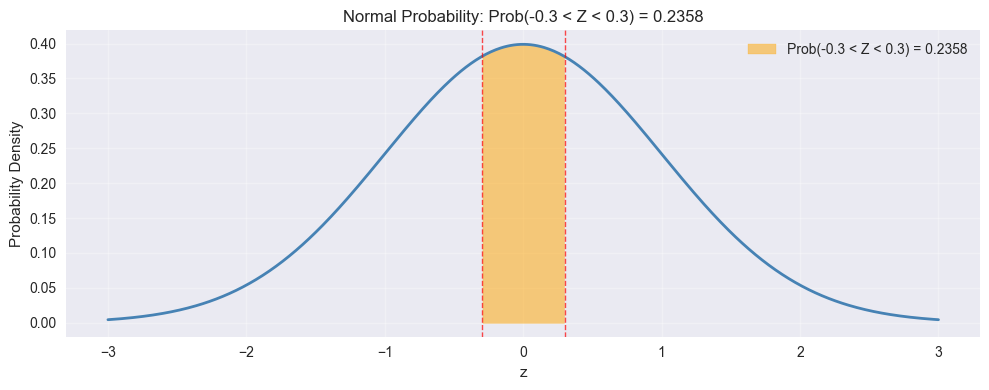

In [11]:
# Cell 4: Calculate normal probabilities
a_val = 0.3
prob_less_a = norm.cdf(a_val)
prob_symmetric = 2 * prob_less_a - 1
prob_greater_a = 1 - prob_less_a

print(f"Example: Prob(-{a_val} < Z < {a_val}):")
print(f"  N({a_val}) = {prob_less_a:.4f}")
print(f"  2·N({a_val}) - 1 = 2·{prob_less_a:.4f} - 1 = {prob_symmetric:.4f}")
print(f"  Prob(Z < -{a_val}) = N(-{a_val}) = {norm.cdf(-a_val):.4f}")
print(f"  Prob(Z > {a_val}) = 1 - N({a_val}) = {prob_greater_a:.4f}")

print("\nMore probability examples:")
for threshold in [-2, -1, 0, 1, 2]:
    print(f"  N({threshold:2}) = {norm.cdf(threshold):.4f}")

# Visualize the symmetric interval example
fig, ax = plt.subplots(figsize=(10, 4))
x_range = np.linspace(-3, 3, 500)
pdf_values = norm.pdf(x_range)
ax.plot(x_range, pdf_values, 'steelblue', linewidth=2)

# Highlight the interval [-0.3, 0.3]
x_interval = x_range[(x_range >= -a_val) & (x_range <= a_val)]
ax.fill_between(x_interval, norm.pdf(x_interval), alpha=0.5, color='orange', label=f'Prob(-{a_val} < Z < {a_val}) = {prob_symmetric:.4f}')

ax.axvline(-a_val, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(a_val, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title(f'Normal Probability: Prob(-{a_val} < Z < {a_val}) = {prob_symmetric:.4f}')
ax.set_xlabel('z')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Converting Between Normal and Standard Normal

If $X \sim N(\mu, \sigma^2)$ (a normal random variable with mean $\mu$ and standard deviation $\sigma$), we can convert it to standard normal using:

$$Z = \frac{X - \mu}{\sigma}, \quad Z \sim N(0,1).$$

Conversely, if $Z \sim N(0,1)$, we can create $X$ with any desired mean and variance:

$$X = \mu + \sigma Z, \quad X \sim N(\mu, \sigma^2).$$

* Example Suppose $X \sim N(5, 9)$ (mean 5, variance 9, so $\sigma = 3$). Then:
- At boundary $x=8$, $Z = \frac{8-5}{3} = 1$.
- Left side of boundary: $\mathbb{P}(X < 8) = N(1) = 0.8413$.
- Right side of boundary: $\mathbb{P}(X > 8) = 1 - N(1) = 0.1587$.
- The boundaries of a 95% confidence interval around the mean are $5 \pm 1.96 \cdot 3 = 5 \pm 5.88$.
- So the 95% confidence interval is $[-0.88, 10.88]$.

Example 18.2: X ~ N(5.0, 9.0) [mean 5.0, variance 9.0, σ = 3.0]
  Boundary at x = 8.0:
    Convert: Z = (8.0 - 5.0)/3.0 = 1.0
    Left side:  P(X < 8.0) = N(1.0) = 0.8413
    Right side: P(X > 8.0) = 1 - N(1.0) = 0.1587

  95% Confidence Interval:
    [5.0 ± 1.96·3.0] = [-0.88, 10.88]


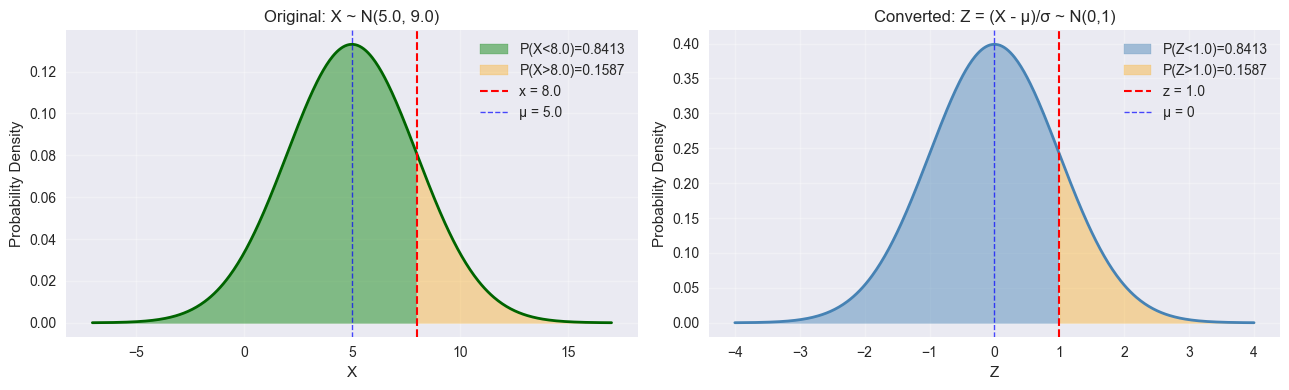

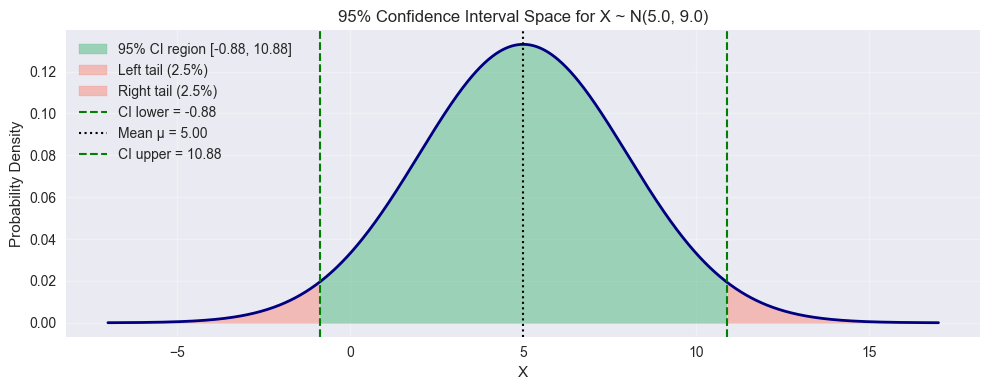


Central interval probability: 0.9500 (about 95%)


In [12]:
#  Example - Normal conversion
mu_ex = 5.0
sigma_ex = 3.0
x_threshold = 8.0

# Convert to standard normal
z_converted = (x_threshold - mu_ex) / sigma_ex
prob_x_less_8 = norm.cdf(z_converted)
prob_x_greater_8 = 1.0 - prob_x_less_8

# Confidence interval
z_95 = norm.ppf(0.975)  # 1.96 for 95% CI
ci_lower = mu_ex - z_95 * sigma_ex
ci_upper = mu_ex + z_95 * sigma_ex
ci_probability = norm.cdf(z_95) - norm.cdf(-z_95)

print(f"Example 18.2: X ~ N({mu_ex}, {sigma_ex**2}) [mean {mu_ex}, variance {sigma_ex**2}, σ = {sigma_ex}]")
print(f"  Boundary at x = {x_threshold}:")
print(f"    Convert: Z = ({x_threshold} - {mu_ex})/{sigma_ex} = {z_converted}")
print(f"    Left side:  P(X < {x_threshold}) = N({z_converted}) = {prob_x_less_8:.4f}")
print(f"    Right side: P(X > {x_threshold}) = 1 - N({z_converted}) = {prob_x_greater_8:.4f}")
print(f"\n  95% Confidence Interval:")
print(f"    [{mu_ex} ± {z_95:.2f}·{sigma_ex}] = [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualize boundary probabilities
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Original distribution X ~ N(5, 9)
x_range = np.linspace(mu_ex - 4 * sigma_ex, mu_ex + 4 * sigma_ex, 500)
pdf_x = norm.pdf(x_range, loc=mu_ex, scale=sigma_ex)
axes[0].plot(x_range, pdf_x, 'darkgreen', linewidth=2)
x_fill_left = x_range[x_range <= x_threshold]
x_fill_right = x_range[x_range > x_threshold]
axes[0].fill_between(
    x_fill_left,
    norm.pdf(x_fill_left, loc=mu_ex, scale=sigma_ex),
    alpha=0.45,
    color='green',
    label=f'P(X<{x_threshold})={prob_x_less_8:.4f}'
)
axes[0].fill_between(
    x_fill_right,
    norm.pdf(x_fill_right, loc=mu_ex, scale=sigma_ex),
    alpha=0.35,
    color='orange',
    label=f'P(X>{x_threshold})={prob_x_greater_8:.4f}'
)
axes[0].axvline(x_threshold, color='red', linestyle='--', linewidth=1.5, label=f'x = {x_threshold}')
axes[0].axvline(mu_ex, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'μ = {mu_ex}')
axes[0].set_title(f'Original: X ~ N({mu_ex}, {sigma_ex**2})')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Converted standard normal
z_range = np.linspace(-4, 4, 500)
pdf_z = norm.pdf(z_range)
axes[1].plot(z_range, pdf_z, 'steelblue', linewidth=2)
z_fill_left = z_range[z_range <= z_converted]
z_fill_right = z_range[z_range > z_converted]
axes[1].fill_between(
    z_fill_left,
    norm.pdf(z_fill_left),
    alpha=0.45,
    color='steelblue',
    label=f'P(Z<{z_converted:.1f})={prob_x_less_8:.4f}'
)
axes[1].fill_between(
    z_fill_right,
    norm.pdf(z_fill_right),
    alpha=0.35,
    color='orange',
    label=f'P(Z>{z_converted:.1f})={prob_x_greater_8:.4f}'
)
axes[1].axvline(z_converted, color='red', linestyle='--', linewidth=1.5, label=f'z = {z_converted}')
axes[1].axvline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='μ = 0')
axes[1].set_title('Converted: Z = (X - μ)/σ ~ N(0,1)')
axes[1].set_xlabel('Z')
axes[1].set_ylabel('Probability Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Additional graph: 95% confidence interval space around the mean
fig, ax = plt.subplots(figsize=(10, 4))
x_ci = np.linspace(mu_ex - 4 * sigma_ex, mu_ex + 4 * sigma_ex, 800)
pdf_ci = norm.pdf(x_ci, loc=mu_ex, scale=sigma_ex)
ax.plot(x_ci, pdf_ci, color='navy', linewidth=2)

x_center = x_ci[(x_ci >= ci_lower) & (x_ci <= ci_upper)]
x_left_tail = x_ci[x_ci < ci_lower]
x_right_tail = x_ci[x_ci > ci_upper]

ax.fill_between(
    x_center,
    norm.pdf(x_center, loc=mu_ex, scale=sigma_ex),
    color='mediumseagreen',
    alpha=0.45,
    label=f'95% CI region [{ci_lower:.2f}, {ci_upper:.2f}]'
)
ax.fill_between(
    x_left_tail,
    norm.pdf(x_left_tail, loc=mu_ex, scale=sigma_ex),
    color='tomato',
    alpha=0.35,
    label='Left tail (2.5%)'
)
ax.fill_between(
    x_right_tail,
    norm.pdf(x_right_tail, loc=mu_ex, scale=sigma_ex),
    color='tomato',
    alpha=0.35,
    label='Right tail (2.5%)'
)

ax.axvline(ci_lower, color='green', linestyle='--', linewidth=1.5, label=f'CI lower = {ci_lower:.2f}')
ax.axvline(mu_ex, color='black', linestyle=':', linewidth=1.5, label=f'Mean μ = {mu_ex:.2f}')
ax.axvline(ci_upper, color='green', linestyle='--', linewidth=1.5, label=f'CI upper = {ci_upper:.2f}')

ax.set_title(f'95% Confidence Interval Space for X ~ N({mu_ex}, {sigma_ex**2})')
ax.set_xlabel('X')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCentral interval probability: {ci_probability:.4f} (about 95%)")

## Sum of Normal Random Variables

A key property is that the sum of normally distributed random variables is also normally distributed.

If $x_i \sim N(\mu_i, \sigma_i^2)$ for $i = 1, \ldots, n$, then their sum $Y = \sum_{i=1}^n x_i$ is normal with:

$$Y \sim N\left(\sum_{i=1}^n \mu_i, \sum_{i=1}^n \sigma_i^2 + 2\sum_{i<j} \text{Cov}(x_i, x_j)\right).$$

For independent variables (covariances = 0):

$$Y \sim N\left(\sum_{i=1}^n \mu_i, \sum_{i=1}^n \sigma_i^2\right).$$

This is crucial for modeling continuously compounded returns over multiple periods: if period returns are i.i.d. normal, then the multi-period return is normal.

Sum of 40 Normal Variables (Independent Periods)
  Each period: return ~ N(0.02, 0.0025000000000000005)

  Theoretical 40-period return ~ N(0.8, 0.10000000000000002):
    Mean:     0.800000
    Std Dev:  0.316228

  Simulated (100000 simulations):
    Mean:     0.799876
    Std Dev:  0.317206


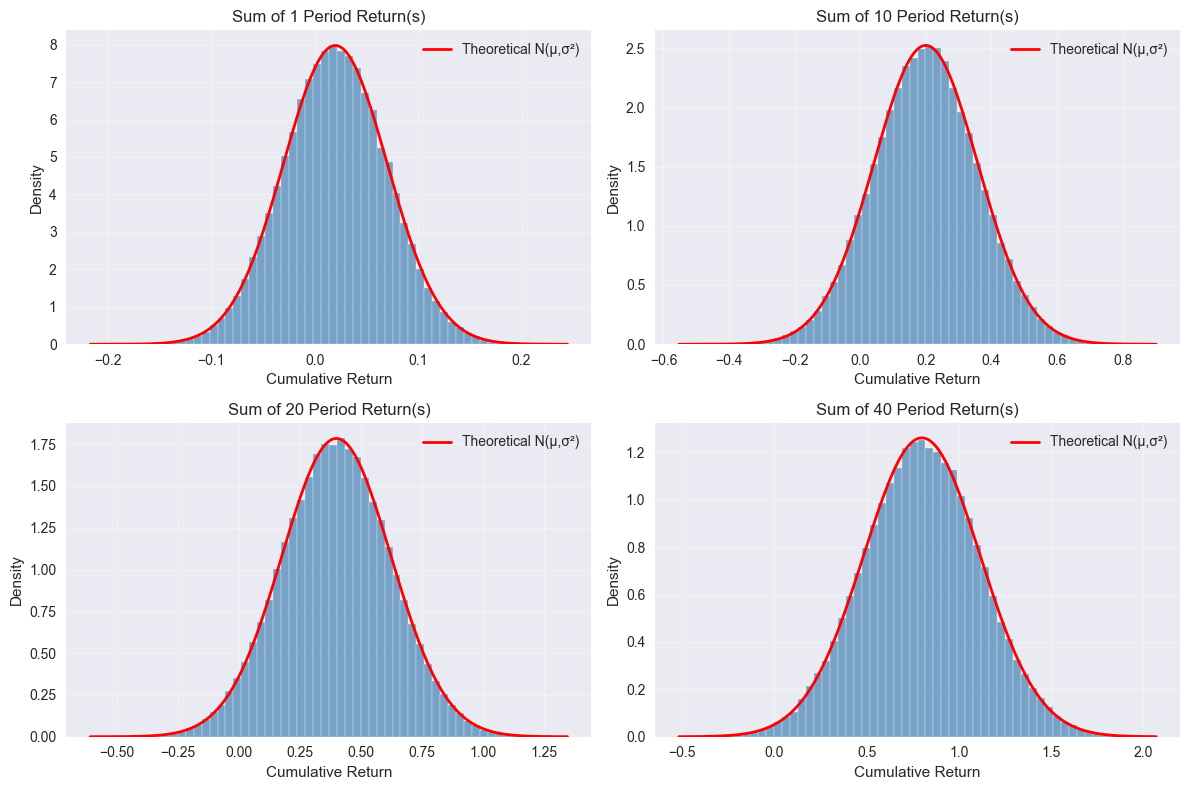


This demonstrates that E[Sum] = 40·μ and Var[Sum] = 40·σ²
Plotted representative horizons: [1, 10, 20, 40]


In [17]:
#  Sum of normal variables simulation
n_periods = 40
mu_period = 0.02
sigma_period = 0.05
n_sims = 100_000

# Simulate period-by-period returns
returns = rng.normal(loc=mu_period, scale=sigma_period, size=(n_sims, n_periods))

# Cumulative (sum) return over all periods
cumulative_return = returns.sum(axis=1)

# Theoretical moments
theoretical_mean = n_periods * mu_period
theoretical_variance = n_periods * sigma_period**2
theoretical_std = np.sqrt(theoretical_variance)

# Simulated moments
simulated_mean = cumulative_return.mean()
simulated_std = cumulative_return.std(ddof=1)

print(f"Sum of {n_periods} Normal Variables (Independent Periods)")
print(f"  Each period: return ~ N({mu_period}, {sigma_period**2})")
print(f"\n  Theoretical {n_periods}-period return ~ N({theoretical_mean}, {theoretical_variance}):")
print(f"    Mean:     {theoretical_mean:.6f}")
print(f"    Std Dev:  {theoretical_std:.6f}")
print(f"\n  Simulated ({n_sims} simulations):")
print(f"    Mean:     {simulated_mean:.6f}")
print(f"    Std Dev:  {simulated_std:.6f}")

# Plot representative horizons so the visualization works for any n_periods
if n_periods <= 4:
    plot_periods = list(range(1, n_periods + 1))
else:
    plot_periods = sorted(set([1, max(2, n_periods // 4), max(3, n_periods // 2), n_periods]))

n_plots = len(plot_periods)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for axis, period_count in zip(axes, plot_periods):
    partial_sum = returns[:, :period_count].sum(axis=1)
    expected_partial = period_count * mu_period
    std_partial = np.sqrt(period_count * sigma_period**2)

    axis.hist(partial_sum, bins=60, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    x_plot = np.linspace(partial_sum.min(), partial_sum.max(), 200)
    axis.plot(
        x_plot,
        norm.pdf(x_plot, loc=expected_partial, scale=std_partial),
        'red',
        linewidth=2,
        label='Theoretical N(μ,σ²)'
    )
    axis.set_title(f'Sum of {period_count} Period Return(s)')
    axis.set_xlabel('Cumulative Return')
    axis.set_ylabel('Density')
    axis.legend()
    axis.grid(alpha=0.3)

for axis in axes[n_plots:]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nThis demonstrates that E[Sum] = {n_periods}·μ and Var[Sum] = {n_periods}·σ²")
print(f"Plotted representative horizons: {plot_periods}")

## From Normal to Lognormal

$Y = e^X$, then $Y$ is always positive and is said to be lognormal.

Stock prices should not become negative in the standard continuous-time model.


$Y = e^X$,


$$X \sim N(\mu, \sigma^2),$$


If $Y$ is lognormal and $\ln(Y) \sim N(m, v^2)$, then the lognormal density can be written as

$$g(y; m, v) = \frac{1}{y v \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{\ln(y) - m}{v}\right)^2}, \quad y > 0.$$

This means the logarithm of the variable is normal with mean $m$ and standard deviation $v$. 


### For Doubble Check: 

If $x$ $\sim N(m, v^2)$, then the mean and variance are

$$\mathbb{E}[e^x] = e^{m + \frac{1}{2}v^2}$$

and

$$\mathrm{Var}(e^x) = \left(e^{v^2} - 1\right)e^{2m + v^2}.$$

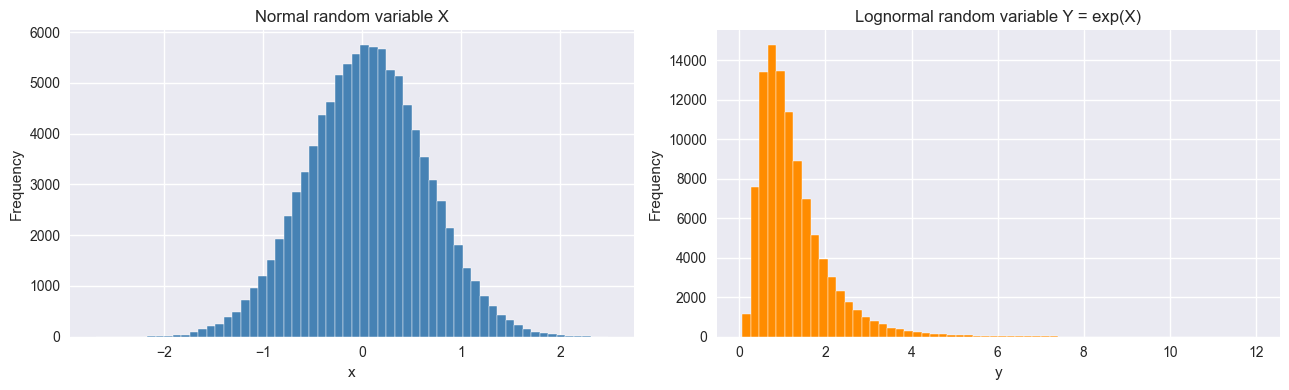

Sample mean of X: 0.0497
Sample std of X:  0.5997
Minimum of Y:     0.0677
Sample mean of Y: 1.2578
Sample std of Y:  0.8254

 mean of Y: 1.2581
 standard deviation of Y: 0.8277


In [31]:
#  Simulate a normal variable and exponentiate it
mu = 0.05
sigma = 0.60
n = 100_000

x = rng.normal(loc=mu, scale=sigma, size=n)
y = np.exp(x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(x, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Normal random variable X')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Frequency')

axes[1].hist(y, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Lognormal random variable Y = exp(X)')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Sample mean of X: {x.mean():.4f}')
print(f'Sample std of X:  {x.std(ddof=1):.4f}')
print(f'Minimum of Y:     {y.min():.4f}')
print(f'Sample mean of Y: {y.mean():.4f}')
print(f'Sample std of Y:  {y.std(ddof=1):.4f}')

#### Check - Lognormal moments from normal moments
mean_1 = np.exp(x.mean() + 0.5*(x.std(ddof=1)**2))
var_1 = (np.exp( x.std(ddof=1)**2) - 1) * np.exp(2*x.mean() +  x.std(ddof=1)**2)
std_1 = np.sqrt(var_1)

print(f"\n mean of Y: {mean_1:.4f}")
print(f" standard deviation of Y: {std_1:.4f}")

## Theoretical Moments of a Lognormal Variable

If $Y$ is lognormal and $\ln(Y) \sim N(m, v^2)$, then the lognormal density can be written as

$$g(y; m, v) = \frac{1}{y v \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{\ln(y) - m}{v}\right)^2}, \quad y > 0.$$

This means the logarithm of the variable is normal with mean $m$ and standard deviation $v$. 

If $x$ $\sim N(m, v^2)$, then the mean and variance are

$$\mathbb{E}[e^x] = e^{m + \frac{1}{2}v^2}$$

and

$$\mathrm{Var}(e^x) = \left(e^{v^2} - 1\right)e^{2m + v^2}.$$

The next cell compares those formulas with simulated sample moments. This is a useful check because it ties the theory directly to the code.

In [ ]:
# Compare simulated and theoretical moments
theoretical_mean = lognormal_mean(mu, sigma)
theoretical_variance = lognormal_variance(mu, sigma)

comparison = pd.DataFrame(
    {
        'Quantity': ['Mean', 'Variance', 'Std. Dev.'],
        'Theoretical': [
            theoretical_mean,
            theoretical_variance,
            np.sqrt(theoretical_variance),
        ],
        'Sample': [
            y.mean(),
            y.var(ddof=1),
            y.std(ddof=1),
        ],
    }
)

comparison['Difference'] = comparison['Sample'] - comparison['Theoretical']
comparison.round(4)

,Quantity,Theoretical,Sample,Difference
0,Mean,1.2586,1.2613,0.0027
1,Variance,0.6864,0.7000,0.0136
2,Std. Dev.,0.8285,0.8366,0.0081


## Lognormal Model of Stock Prices

A standard one-period stock-price model with continuous dividend yield writes the terminal price as

$$S_T = S_0 e^{R},$$

where $R$ is the continuously compounded ex-dividend return over the horizon. If $R$ is normal, then $S_T$ is lognormal.

In the geometric Brownian motion framework with dividends,

$$S_T = S_0 e^{\left(r - q - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}Z}, \quad Z \sim N(0,1),$$

where $r$ is the expected return, $q$ is the continuous dividend yield, and $\sigma$ is volatility.

The next cell simulates many one-year terminal prices and summarizes the resulting distribution.

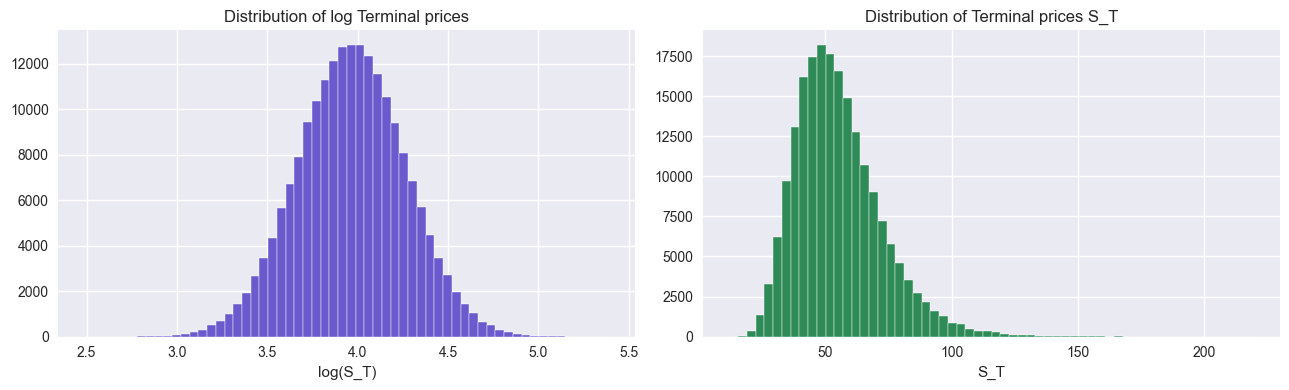

count    200000.0000
mean         55.2231
std          16.9200
min          12.0565
5%           32.2347
50%          52.8320
95%          86.3409
max         219.4950
Name: S_T, dtype: float64

In [30]:
# Cell 8: Simulate one-year terminal stock prices under a lognormal model with dividends
S0 = 50
mu_annual = 0.10
sigma_annual = 0.30
q_annual = 0 # Continuous dividend yield
T = 1.0
n_paths = 200_000

z = rng.standard_normal(n_paths)
log_ST = np.log(S0) + (mu_annual - q_annual - 0.5 * sigma_annual**2) * T + sigma_annual * np.sqrt(T) * z
ST = np.exp(log_ST)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(log_ST, bins=60, color='slateblue', edgecolor='white')
axes[0].set_title('Distribution of log Terminal prices')
axes[0].set_xlabel('log(S_T)')

axes[1].hist(ST, bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of Terminal prices S_T')
axes[1].set_xlabel('S_T')

plt.tight_layout()
plt.show()

terminal_summary = pd.Series(ST).describe(percentiles=[0.05, 0.5, 0.95]).rename('S_T')
terminal_summary.round(4)

## Parameter Sensitivity Analysis

To see how the lognormal model spreads prices over time, fix the starting stock price at $S_0 = 50$ and compute model-implied prices at several horizons.

For each horizon $T$, the price at a given standard-normal location $k$ is
$$S_T(k) = S_0 e^{(\mu - q - \tfrac{1}{2}\sigma^2)T + k\sigma\sqrt{T}}, \quad k \in \{-3,-2,-1,0,1,2,3\}.$$

The first column lists the time horizon from 1 day through 5 years. The remaining columns show the corresponding stock price at each standard deviation level under the model.

In [260]:
# Cell 10: Model-implied stock prices by horizon and standard deviation level
S0_sensitivity = 50.0

# Match the slide-style assumptions used for this table.
mu_model_surface = 0.15
sigma_model_surface = 0.30
q_model_surface = 0.0

horizon_map = [
    ('1 Day', 1 / 365),
    ('1 Month', 31 / 365),
    ('1 Year', 1.0),
    ('2 Years', 2.0),
    ('5 Years', 5.0),
]

sigma_levels = [-2, -1, 1, 2]
rows = []

for period_label, T_years in horizon_map:
    drift = (mu_model_surface - q_model_surface - 0.5 * sigma_model_surface**2) * T_years
    row = {
        'Horizon': period_label,
        'Fraction of a Year': T_years,
    }

    for sigma_level in sigma_levels:
        modeled_price = S0_sensitivity * np.exp(
            drift + sigma_level * sigma_model_surface * np.sqrt(T_years)
        )
        row[f'{sigma_level:+d}σ'] = modeled_price

    rows.append(row)

price_surface = pd.DataFrame(rows)
display_columns = ['Horizon', 'Fraction of a Year'] + [f'{sigma_level:+d}σ' for sigma_level in sigma_levels]

result = price_surface[display_columns].copy()
result['Fraction of a Year'] = result['Fraction of a Year'].round(4)
for column in [f'{sigma_level:+d}σ' for sigma_level in sigma_levels]:
    result[column] = result[column].round(2)

result

,Horizon,Fraction of a Year,-2σ,-1σ,+1σ,+2σ
0,1 Day,0.0027,48.47,49.24,50.81,51.61
1,1 Month,0.0849,42.35,46.22,55.06,60.09
2,1 Year,1.0000,30.48,41.14,74.97,101.19
3,2 Years,2.0000,26.40,40.36,94.28,144.11
4,5 Years,5.0000,22.10,43.22,165.31,323.33


## Discussion: Why $\Pr(S_t < K)$ Becomes a Normal CDF


With continuous payout yield $\delta$,

$$S_t = S_0\exp\left[(r-\delta-\tfrac{1}{2}\sigma^2)t + \sigma\sqrt{t}\,Z\right],\quad Z\sim N(0,1).$$

So

$$\ln\left(\frac{S_t}{S_0}\right)= (r-\delta-\tfrac{1}{2}\sigma^2)t + \sigma\sqrt{t}\,Z.$$

### Solve Explicitly For $Z$

Starting from

$$\ln\left(\frac{S_t}{S_0}\right)= (r-\delta-\tfrac{1}{2}\sigma^2)t + \sigma\sqrt{t}\,Z,$$

subtract the drift term from both sides:

$$\ln\left(\frac{S_t}{S_0}\right)- (r-\delta-\tfrac{1}{2}\sigma^2)t = \sigma\sqrt{t}\,Z,$$

then divide by $\sigma\sqrt{t}$:

$$Z = \frac{\ln(S_t/S_0)- (r-\delta-\tfrac{1}{2}\sigma^2)t}{\sigma\sqrt{t}}.$$

Using $\ln(S_t/S_0)=\ln(S_t)-\ln(S_0)$, this is exactly

$$Z = \frac{\ln(S_t)-\ln(S_0)- (r-\delta-\tfrac{1}{2}\sigma^2)t}{\sigma\sqrt{t}}.$$

To compute $\Pr(S_t<K)$, note that $S_t<K \iff \ln(S_t)<\ln(K)$, so

$$\Pr(S_t<K)=N\!\left(\frac{\ln(K)-\ln(S_0)-(r-\delta-\tfrac{1}{2}\sigma^2)t}{\sigma\sqrt{t}}\right).$$

This is algebraically identical to

$$\Pr(S_t<K)=N(-\hat d_2),\quad \hat d_2=\frac{\ln(S_0/K)+(\alpha-\delta-\tfrac{1}{2}\sigma^2)t}{\sigma\sqrt{t}}.$$



## Real Data Example: AAPL Log Returns and Dividend Yield

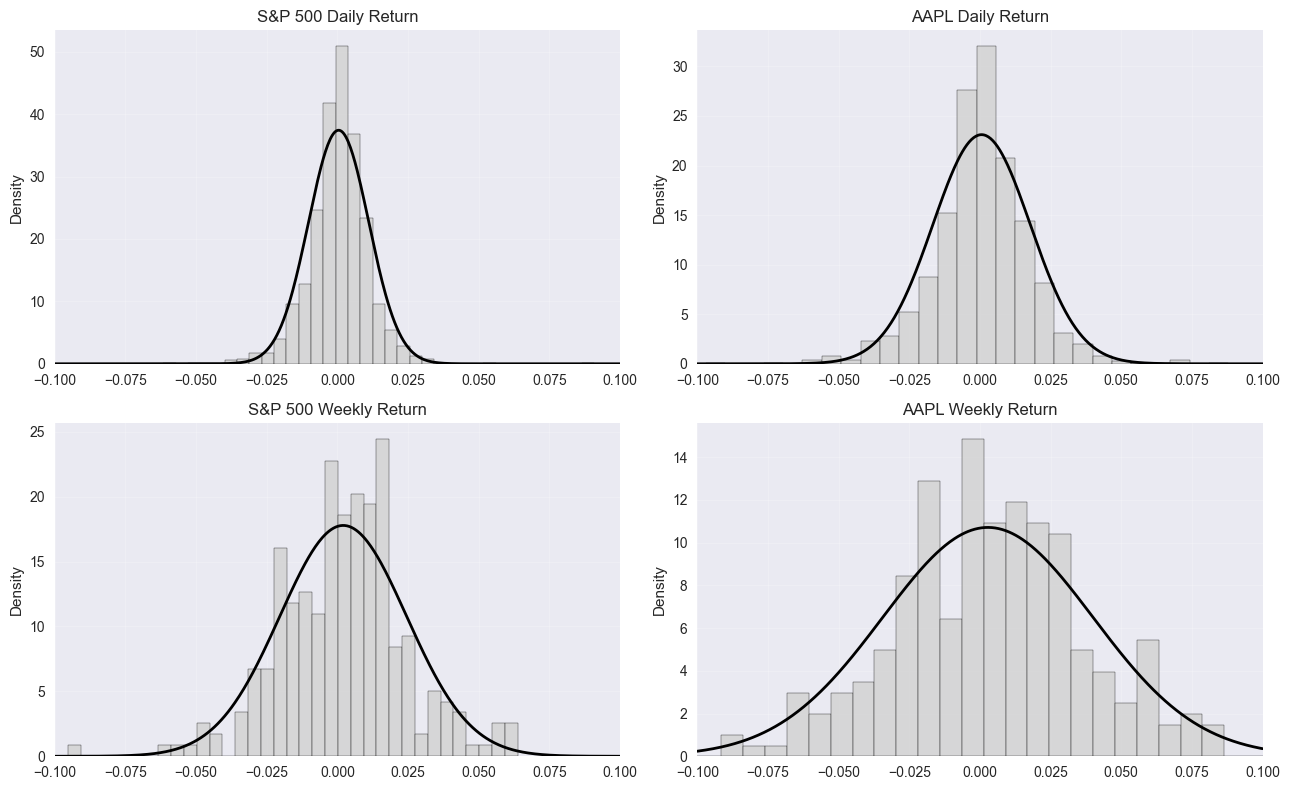

Data source used: Yahoo Finance adjusted close (daily + weekly), AAPL and GSPC
Dividend source used: ignored (set to 0.0)


,Apple Inc. (AAPL),S&P 500 Index (^GSPC)
Daily mean log return,0.000587,0.000427
Daily volatility,0.017260,0.010659
Annualized mean log return (252 days),0.147948,0.107525
Annualized volatility (252 days),0.273988,0.169214
Weekly mean log return,0.002821,0.002050
Weekly volatility,0.037238,0.022431
Annualized mean log return (52 weeks),0.146679,0.106603
Annualized volatility (52 weeks),0.268528,0.161749
Latest adjusted close,273.170013,7137.899902
Annual continuous dividend yield (q),0.000000,0.000000


In [32]:
# Cell 12: Yahoo adjusted-close example (AAPL vs S&P 500), daily and weekly return distributions
import yfinance as yf
from scipy.stats import norm

tickers = ['AAPL', '^GSPC']

def get_adj_close(interval):
    raw = yf.download(
        tickers=tickers,
        period='5y',
        interval=interval,
        auto_adjust=False,
        progress=False,
        group_by='column',
    )

    if raw.empty:
        raise ValueError(f'No data returned from Yahoo Finance for interval={interval}.')

    if not isinstance(raw.columns, pd.MultiIndex):
        raise ValueError('Unexpected Yahoo data format for multiple tickers.')

    if ('Adj Close', 'AAPL') in raw.columns and ('Adj Close', '^GSPC') in raw.columns:
        prices = pd.DataFrame({
            'AAPL': raw[('Adj Close', 'AAPL')],
            'GSPC': raw[('Adj Close', '^GSPC')],
        })
    else:
        prices = pd.DataFrame({
            'AAPL': raw[('Close', 'AAPL')],
            'GSPC': raw[('Close', '^GSPC')],
        })

    return prices.dropna().sort_index()

daily_prices = get_adj_close('1d')
weekly_prices = get_adj_close('1wk')

daily_log_returns = np.log(daily_prices / daily_prices.shift(1)).dropna()
weekly_log_returns = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

# Keep AAPL series compatible with downstream cells.
aapl = daily_log_returns[['AAPL']].rename(columns={'AAPL': 'log_return'}).reset_index()
date_col = 'Date' if 'Date' in aapl.columns else aapl.columns[0]
aapl = aapl.rename(columns={date_col: 'date'})
aapl['date'] = pd.to_datetime(aapl['date'])

# AAPL annualized parameters used downstream in the notebook (daily convention).
mu_daily_hat = daily_log_returns['AAPL'].mean()
sigma_daily_hat = daily_log_returns['AAPL'].std(ddof=1)
mu_annual_hat = mu_daily_hat * 252
sigma_annual_hat = sigma_daily_hat * np.sqrt(252)
S0_aapl = float(daily_prices['AAPL'].iloc[-1])

# Also compute benchmark stats for S&P 500.
mu_daily_gspc = daily_log_returns['GSPC'].mean()
sigma_daily_gspc = daily_log_returns['GSPC'].std(ddof=1)
mu_annual_gspc = mu_daily_gspc * 252
sigma_annual_gspc = sigma_daily_gspc * np.sqrt(252)
S0_gspc = float(daily_prices['GSPC'].iloc[-1])

mu_weekly_hat = weekly_log_returns['AAPL'].mean()
sigma_weekly_hat = weekly_log_returns['AAPL'].std(ddof=1)
mu_annual_weekly_aapl = mu_weekly_hat * 52
sigma_annual_weekly_aapl = sigma_weekly_hat * np.sqrt(52)

mu_weekly_gspc = weekly_log_returns['GSPC'].mean()
sigma_weekly_gspc = weekly_log_returns['GSPC'].std(ddof=1)
mu_annual_weekly_gspc = mu_weekly_gspc * 52
sigma_annual_weekly_gspc = sigma_weekly_gspc * np.sqrt(52)

# User-requested assumption: ignore dividends in this example.
trailing_dividend_per_share = 0.0
q_annual_hat = 0.0
dividend_source = 'ignored (set to 0.0)'
source_used = 'Yahoo Finance adjusted close (daily + weekly), AAPL and GSPC'

def plot_return_panel(ax, series, title):
    ax.hist(series, bins=35, density=True, color='lightgray', edgecolor='black', alpha=0.85)
    x = np.linspace(-0.10, 0.10, 500)
    ax.plot(x, norm.pdf(x, loc=series.mean(), scale=series.std(ddof=1)), color='black', linewidth=2)
    ax.set_xlim(-0.10, 0.10)
    ax.set_title(title)
    ax.set_ylabel('Density')
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_return_panel(axes[0, 0], daily_log_returns['GSPC'], 'S&P 500 Daily Return')
plot_return_panel(axes[0, 1], daily_log_returns['AAPL'], 'AAPL Daily Return')
plot_return_panel(axes[1, 0], weekly_log_returns['GSPC'], 'S&P 500 Weekly Return')
plot_return_panel(axes[1, 1], weekly_log_returns['AAPL'], 'AAPL Weekly Return')
plt.tight_layout()
plt.show()

estimates = pd.DataFrame(
    {
        'Apple Inc. (AAPL)': [
            mu_daily_hat,
            sigma_daily_hat,
            mu_annual_hat,
            sigma_annual_hat,
            mu_weekly_hat,
            sigma_weekly_hat,
            mu_annual_weekly_aapl,
            sigma_annual_weekly_aapl,
            S0_aapl,
            q_annual_hat,
        ],
        'S&P 500 Index (^GSPC)': [
            mu_daily_gspc,
            sigma_daily_gspc,
            mu_annual_gspc,
            sigma_annual_gspc,
            mu_weekly_gspc,
            sigma_weekly_gspc,
            mu_annual_weekly_gspc,
            sigma_annual_weekly_gspc,
            S0_gspc,
            0.0,
        ],
    },
    index=[
        'Daily mean log return',
        'Daily volatility',
        'Annualized mean log return (252 days)',
        'Annualized volatility (252 days)',
        'Weekly mean log return',
        'Weekly volatility',
        'Annualized mean log return (52 weeks)',
        'Annualized volatility (52 weeks)',
        'Latest adjusted close',
        'Annual continuous dividend yield (q)',
    ],
)

print(f'Data source used: {source_used}')
print(f'Dividend source used: {dividend_source}')

table_title = 'Adjusted-Close Return Estimates: Apple Inc. (AAPL) and S&P 500 Index (^GSPC)'
estimates.round(6).style.set_caption(table_title)

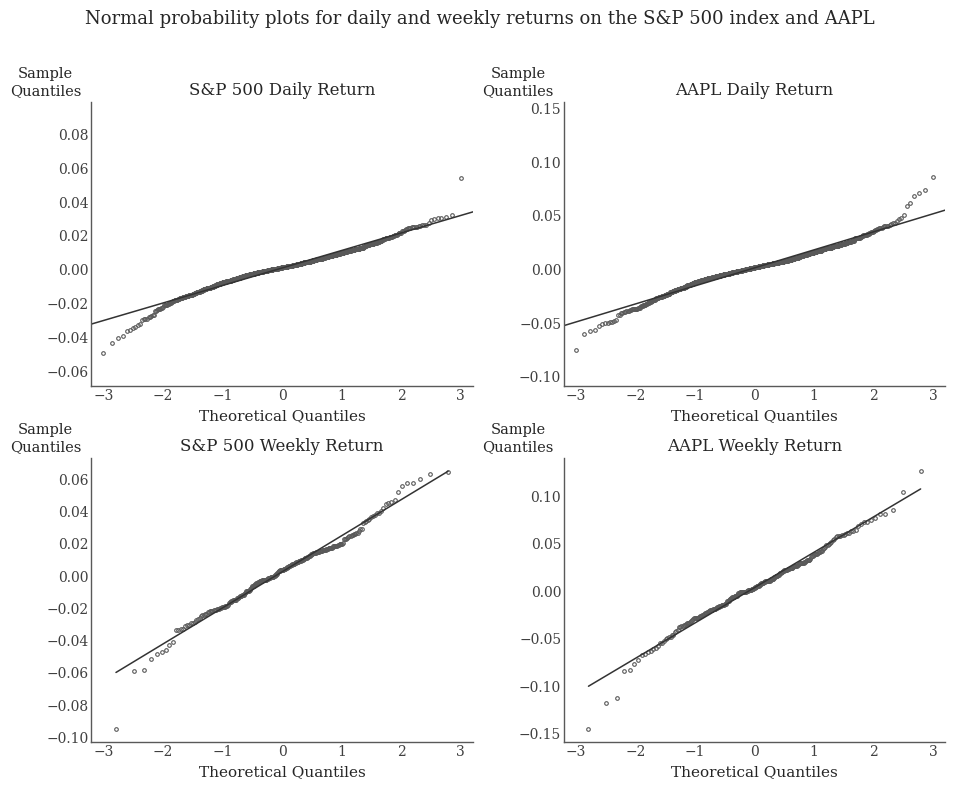

In [284]:
# Cell 12c: QQ plots for daily and weekly returns (slide-style 2x2 layout)
from scipy import stats

# Use the already-computed return series from Cell 12
qq_series = [
    ('S&P 500 Daily Return', daily_log_returns['GSPC'].dropna()),
    ('AAPL Daily Return', daily_log_returns['AAPL'].dropna()),
    ('S&P 500 Weekly Return', weekly_log_returns['GSPC'].dropna()),
    ('AAPL Weekly Return', weekly_log_returns['AAPL'].dropna()),
]

fig, axes = plt.subplots(2, 2, figsize=(9.6, 8.0))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for ax, (title, series) in zip(axes, qq_series):
    (theoretical_q, sample_q), (slope, intercept, _r) = stats.probplot(series, dist='norm')

    # Open circles and reference line to mimic the slide appearance.
    ax.plot(
        theoretical_q, sample_q,
        linestyle='none', marker='o', markersize=2.6,
        markerfacecolor='none', markeredgecolor='0.35', markeredgewidth=0.8
    )
    xline = np.array([np.min(theoretical_q), np.max(theoretical_q)])
    ax.plot(xline, intercept + slope * xline, color='0.2', linewidth=1.1)

    ax.set_facecolor('white')
    ax.set_title(title, fontsize=12, fontfamily='serif', pad=6)
    ax.set_xlabel('Theoretical Quantiles', fontsize=11, fontfamily='serif')
    ax.set_ylabel('Sample\nQuantiles', rotation=0, fontsize=10.5, fontfamily='serif', labelpad=22)
    ax.yaxis.set_label_coords(-0.12, 1.02)
    ax.grid(False)
    ax.set_xlim(-3.2, 3.2)

    # Slide-like frame treatment.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('0.35')
    ax.spines['bottom'].set_color('0.35')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.tick_params(axis='both', colors='0.25', labelsize=10, pad=2)

fig.suptitle(
    'Normal probability plots for daily and weekly returns on the S&P 500 index and AAPL',
    fontsize=13,
    fontfamily='serif',
    y=0.98
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()